Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Load Dataset

In [3]:
df = pd.read_csv("../data/raw/IMDB Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


Dataset Shape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


First 5 Rows

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


Missing Values

In [8]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Duplicate Records

In [9]:
df.duplicated().sum()

np.int64(418)

Check Shape Before Removal

In [10]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (50000, 2)


Remove Duplicates

In [11]:
df = df.drop_duplicates()

Check Shape After Removal

In [12]:
print("After removing duplicates:", df.shape)

After removing duplicates: (49582, 2)


Verify

In [13]:
df.duplicated().sum()

np.int64(0)

Reset Index

In [14]:
df = df.reset_index(drop=True)

Verify Index

In [15]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Save the Cleaned Dataset

In [16]:
df.to_csv(
    "../data/processed/imdb_cleaned.csv",
    index=False
)

## Step 1 Findings

1. Original dataset contained 50,000 reviews.
2. No missing values were found.
3. 418 duplicate reviews were identified.
4. Duplicate reviews were removed.
5. Final dataset contains 49,582 unique reviews.
6. Dataset is ready for exploratory analysis.

# Step 2: Sentiment Distribution Analysis

Understanding the distribution of sentiment labels is important before training machine learning models.

We will analyze:

- Number of Positive Reviews
- Number of Negative Reviews
- Percentage Distribution
- Dataset Balance

In [17]:
# Count sentiment labels

sentiment_counts = df["sentiment"].value_counts()

sentiment_counts

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

## Percentage Distribution

Let's calculate the percentage of reviews belonging to each sentiment category.

In [18]:
# Percentage distribution

sentiment_percentage = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)

sentiment_percentage.round(2)

sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64

## Count Plot of Sentiment Labels

A count plot helps visualize the number of reviews in each sentiment category.

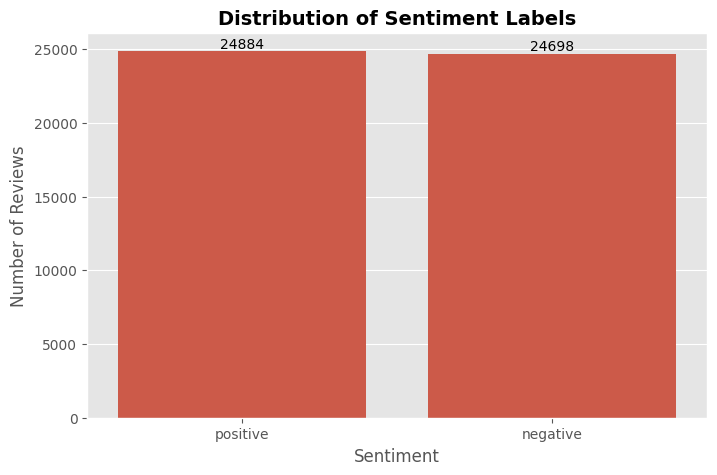

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="sentiment"
)

plt.title(
    "Distribution of Sentiment Labels",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

## Pie Chart Representation

Pie charts provide an intuitive view of the percentage distribution of sentiment classes.

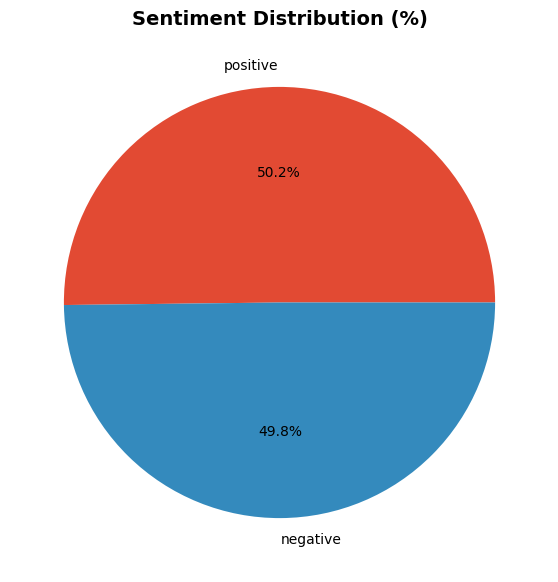

In [20]:
plt.figure(figsize=(7,7))

df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Sentiment Distribution (%)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("")

plt.show()

## Insights

### Observations

1. The dataset contains nearly equal numbers of positive and negative reviews.

2. The sentiment classes are balanced.

3. No class imbalance problem exists.

4. Machine Learning models can be trained without applying resampling techniques such as:
   - Oversampling
   - Undersampling
   - SMOTE

### Conclusion

The IMDb dataset is well-balanced and suitable for sentiment classification tasks.

In [21]:
summary_df = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percentage.round(2)
})

summary_df

,Count,Percentage
sentiment,,
positive,24884,50.19
negative,24698,49.81


# Step 3: Review Length Analysis

Review length is an important characteristic in sentiment analysis.

We will calculate:

- Character Length
- Word Length

and compare them across sentiment categories.

In [22]:
# Character length

df["review_length_char"] = df["review"].apply(len)

# Word length

df["review_length_word"] = df["review"].apply(
    lambda x: len(x.split())
)

df.head()

,review,sentiment,review_length_char,review_length_word
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [23]:
df[
    [
        "review_length_char",
        "review_length_word"
    ]
].head()

,review_length_char,review_length_word
0,1761,307
1,998,162
2,926,166
3,748,138
4,1317,230


## Review Length Statistics

Let's analyze the statistical properties of review lengths.

In [24]:
df[
    [
        "review_length_char",
        "review_length_word"
    ]
].describe()

,review_length_char,review_length_word
count,49582.000000,49582.000000
mean,1310.568230,231.350167
std,990.762238,171.542020
min,32.000000,4.000000
25%,699.000000,126.000000
50%,971.000000,173.000000
75%,1592.000000,281.000000
max,13704.000000,2470.000000


## Distribution of Character Length

Histogram shows how review lengths are distributed.

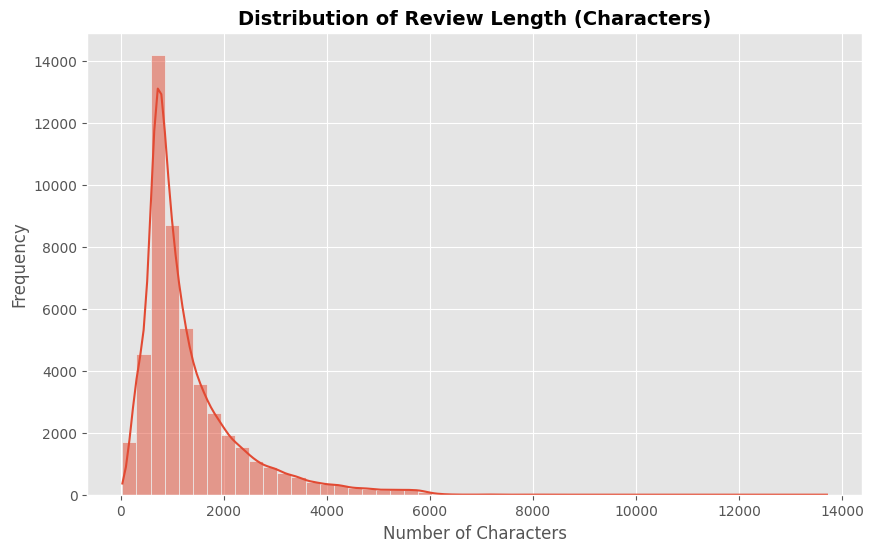

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["review_length_char"],
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Review Length (Characters)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

## Distribution of Word Length

Let's analyze review length in terms of words.

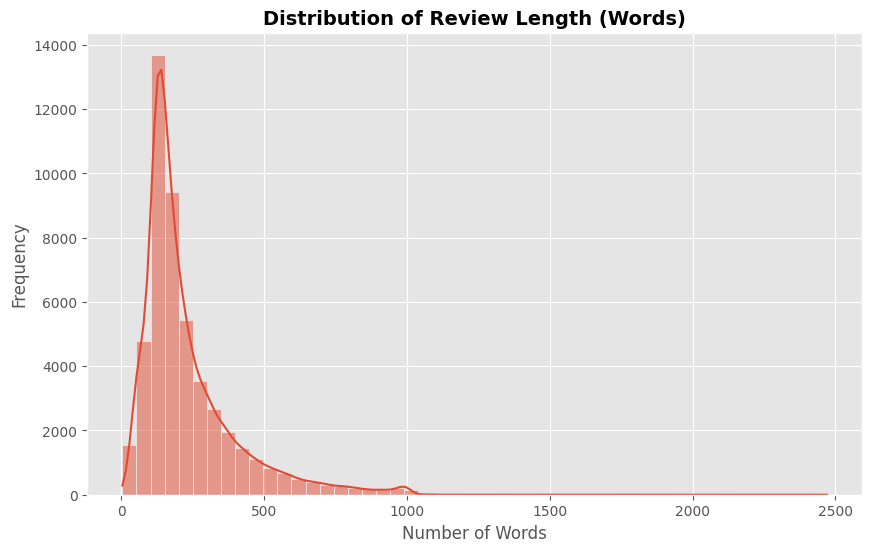

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["review_length_word"],
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Review Length (Words)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

## Average Review Length by Sentiment

Let's compare review lengths across positive and negative reviews.

In [27]:
df.groupby("sentiment")[
    [
        "review_length_char",
        "review_length_word"
    ]
].mean()

,review_length_char,review_length_word
sentiment,,
negative,1294.739615,229.596607
positive,1326.278532,233.090620


# Character Length Boxplot

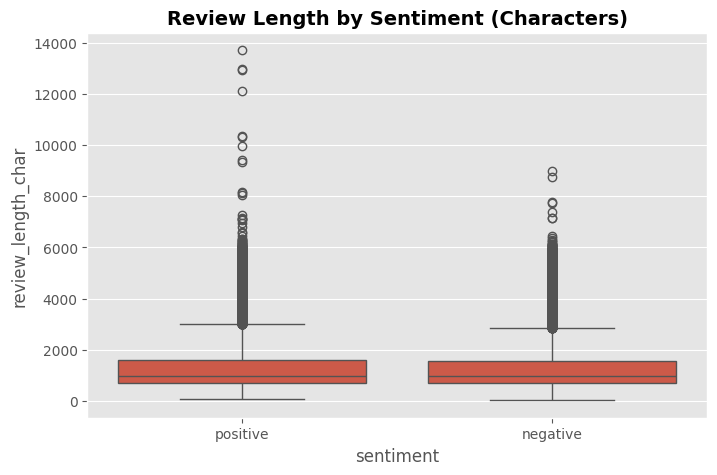

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length_char"
)

plt.title(
    "Review Length by Sentiment (Characters)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# Word Length Boxplot

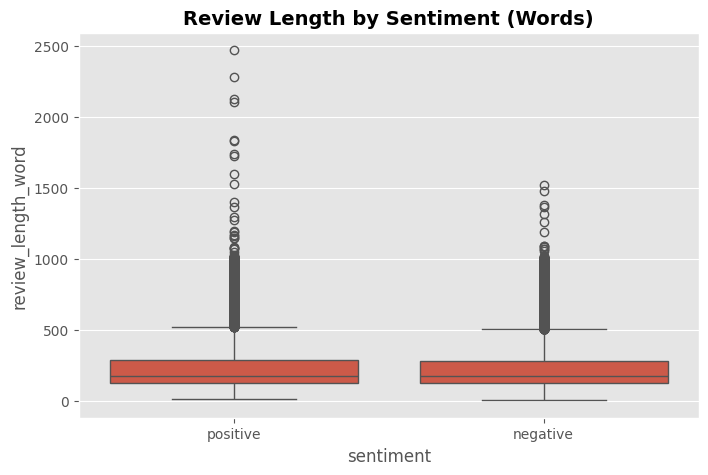

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length_word"
)

plt.title(
    "Review Length by Sentiment (Words)",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# Top 5 Longest Reviews

In [30]:
df[
    [
        "sentiment",
        "review_length_word"
    ]
].sort_values(
    by="review_length_word",
    ascending=False
).head()

,sentiment,review_length_word
31309,positive,2470
40247,positive,2278
31265,positive,2125
31072,positive,2108
12622,positive,1839


# Insights from Review Length Analysis

### Observations

1. Review lengths vary significantly.
2. Most reviews are concentrated around the average length.
3. Some reviews are extremely long outliers.
4. Positive and negative reviews may show differences in average length.
5. Review length could become a useful feature for sentiment prediction.

### Conclusion

Review length provides valuable information about reviewer behavior and may contribute to model performance.

# Step 4: Most Common Words Analysis

In [31]:
from collections import Counter

# Most Common Words Analysis

We combine all reviews into a single corpus and analyze the most frequently occurring words.

In [32]:
all_text = " ".join(df["review"])

print("Total Characters:", len(all_text))

Total Characters: 65030175


In [33]:
words = all_text.lower().split()

print("Total Words:", len(words))

Total Words: 11470804


In [34]:
word_freq = Counter(words)

word_freq.most_common(20)

[('the', 633981),
 ('a', 314408),
 ('and', 311378),
 ('of', 284608),
 ('to', 262599),
 ('is', 203488),
 ('in', 178487),
 ('i', 140393),
 ('this', 137398),
 ('that', 129179),
 ('it', 128655),
 ('/><br', 100211),
 ('was', 92494),
 ('as', 87592),
 ('with', 83950),
 ('for', 83880),
 ('but', 77270),
 ('on', 62404),
 ('movie', 61011),
 ('are', 56594)]

In [35]:
common_words_df = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

common_words_df

,Word,Frequency
0,the,633981
1,a,314408
2,and,311378
3,of,284608
4,to,262599
5,is,203488
6,in,178487
7,i,140393
8,this,137398
9,that,129179


## Top 20 Most Common Words

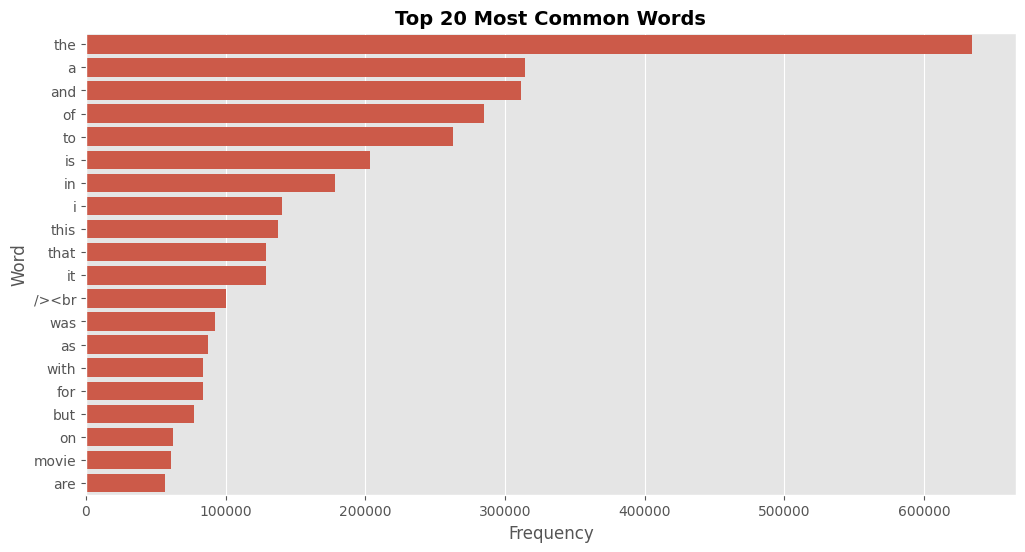

In [36]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_words_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Top 20 Most Common Words",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [37]:
positive_reviews = df[
    df["sentiment"] == "positive"
]["review"]

positive_text = " ".join(positive_reviews)

positive_words = positive_text.lower().split()

positive_freq = Counter(positive_words)

positive_df = pd.DataFrame(
    positive_freq.most_common(20),
    columns=["Word", "Frequency"]
)

positive_df.head()

,Word,Frequency
0,the,325111
1,and,170782
2,a,160440
3,of,150236
4,to,129177


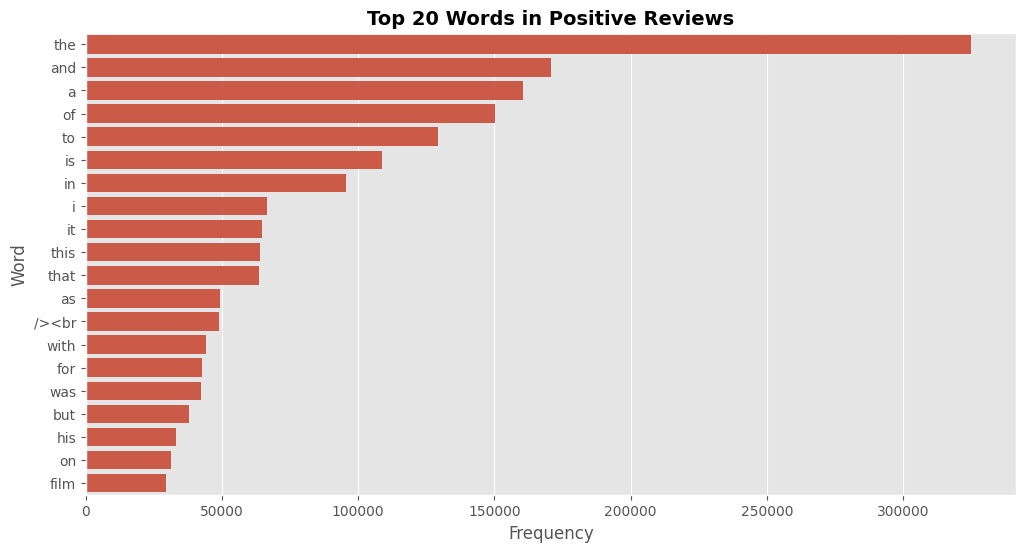

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=positive_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Top 20 Words in Positive Reviews",
    fontsize=14,
    fontweight="bold"
)

plt.show()

In [39]:
negative_reviews = df[
    df["sentiment"] == "negative"
]["review"]

negative_text = " ".join(negative_reviews)

negative_words = negative_text.lower().split()

negative_freq = Counter(negative_words)

negative_df = pd.DataFrame(
    negative_freq.most_common(20),
    columns=["Word", "Frequency"]
)

negative_df.head()

,Word,Frequency
0,the,308870
1,a,153968
2,and,140596
3,of,134372
4,to,133422


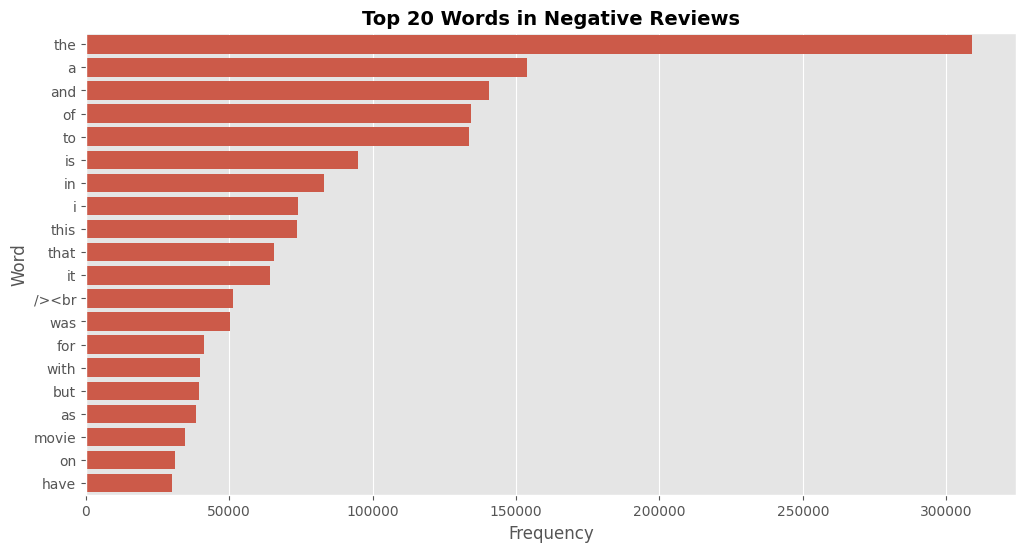

In [40]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=negative_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Top 20 Words in Negative Reviews",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# Insights from Most Common Words Analysis

### Observations

1. Common English stopwords dominate the vocabulary.
2. Positive and negative reviews share many common words.
3. Raw text contains a large amount of noise.
4. Stopwords contribute little to sentiment prediction.

### Conclusion

Text preprocessing will be necessary before model training. Stopword removal and lemmatization are expected to improve feature quality.

# Step 5: Word Cloud Analysis

Word Clouds provide a visual representation of the most frequently occurring words.

Larger words indicate higher frequency.

In [41]:
from wordcloud import WordCloud

In [42]:
all_reviews_text = " ".join(df["review"])

In [43]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_reviews_text)

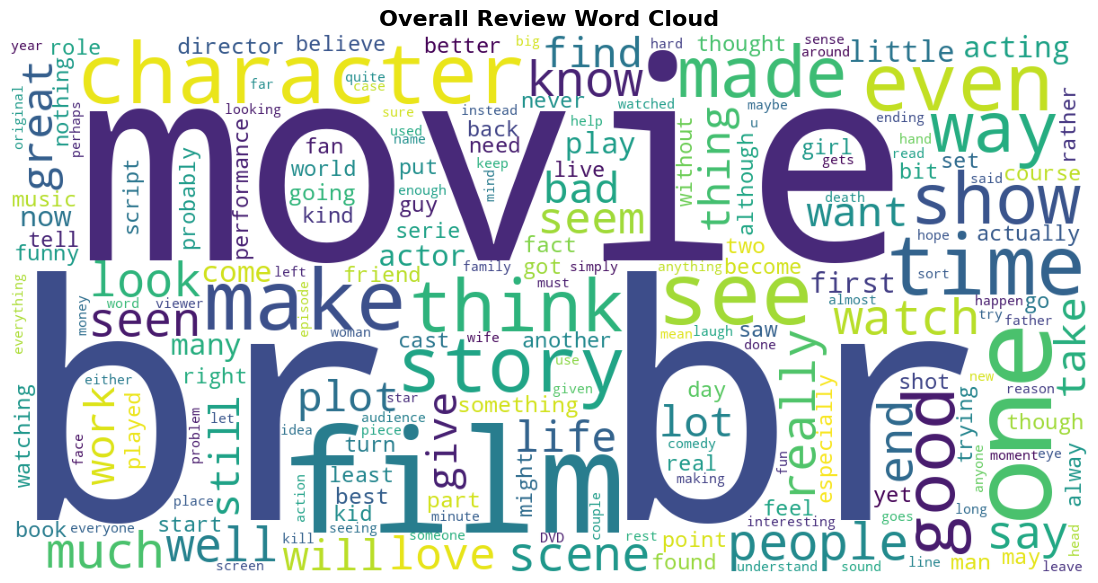

In [44]:
plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Overall Review Word Cloud",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [45]:
positive_reviews = df[
    df["sentiment"] == "positive"
]["review"]

positive_text = " ".join(positive_reviews)

In [46]:
positive_cloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(positive_text)

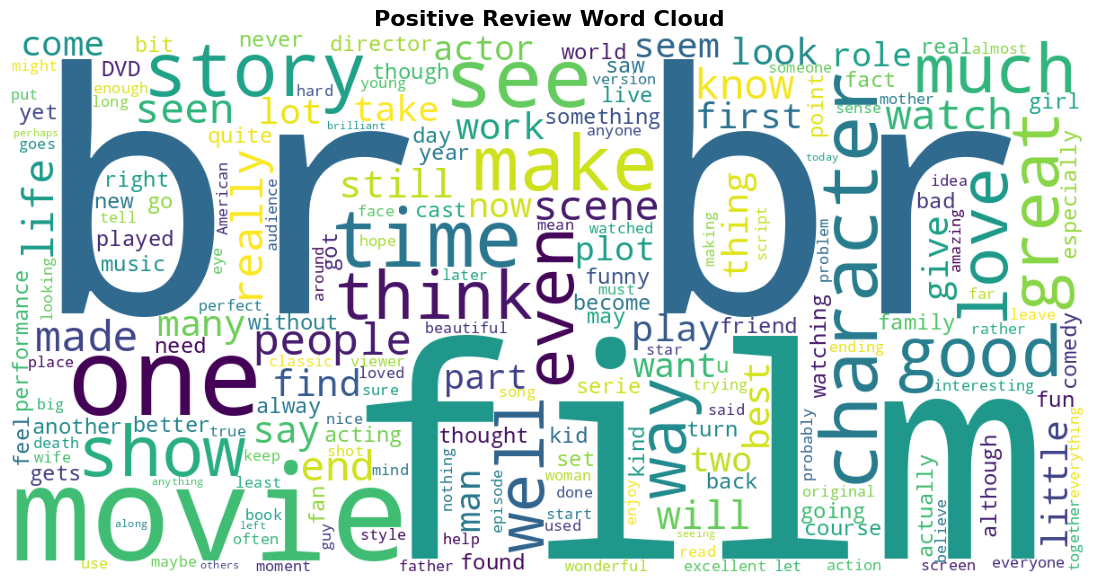

In [47]:
plt.figure(figsize=(15,7))

plt.imshow(positive_cloud)

plt.axis("off")

plt.title(
    "Positive Review Word Cloud",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [48]:
negative_reviews = df[
    df["sentiment"] == "negative"
]["review"]

negative_text = " ".join(negative_reviews)

In [49]:
negative_cloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(negative_text)

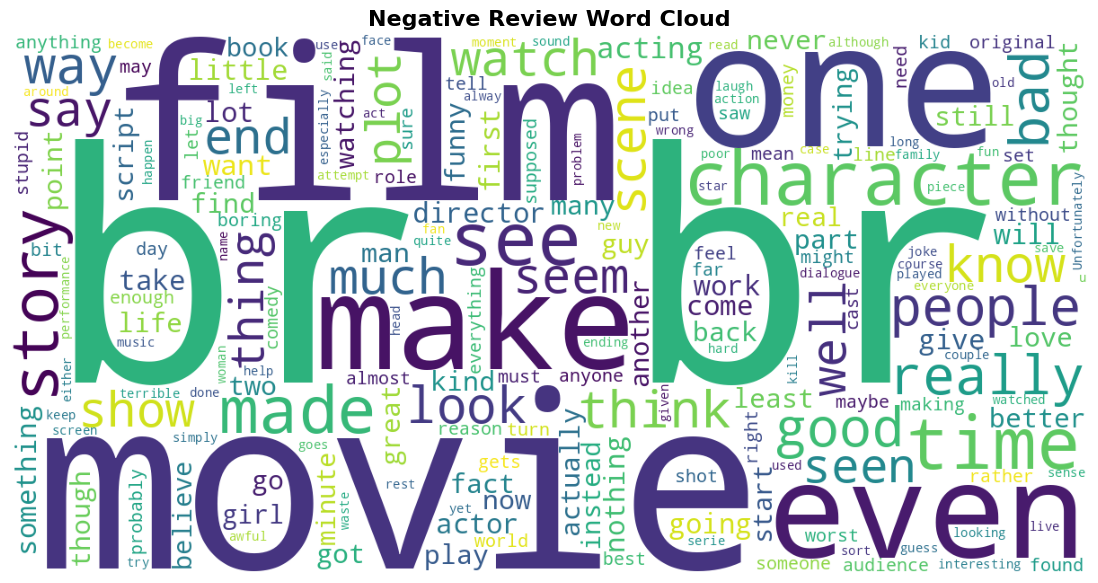

In [50]:
plt.figure(figsize=(15,7))

plt.imshow(negative_cloud)

plt.axis("off")

plt.title(
    "Negative Review Word Cloud",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [51]:
wordcloud.to_file(
    "../reports/figures/overall_wordcloud.png"
)

In [52]:
positive_cloud.to_file(
    "../reports/figures/positive_wordcloud.png"
)

In [53]:
negative_cloud.to_file(
    "../reports/figures/negative_wordcloud.png"
)

# Insights from Word Cloud Analysis

### Observations

1. Frequently occurring words appear larger.
2. Positive reviews emphasize appreciation and recommendation.
3. Negative reviews emphasize dissatisfaction and criticism.
4. Several common English stopwords dominate the clouds.

### Conclusion

The presence of many stopwords highlights the need for text preprocessing before model training.

# Phase 2 Conclusion

## Key Findings

1. The dataset contains 49,582 unique reviews after duplicate removal.
2. No missing values were found.
3. The dataset is balanced between positive and negative sentiments.
4. Review lengths vary significantly across samples.
5. Common English stopwords dominate the vocabulary.
6. Word clouds reveal frequent terms but also highlight noise in the text.

## Next Steps

To prepare the dataset for machine learning and deep learning models, text preprocessing is required.

The next phase will focus on:
- Text cleaning
- Stopword removal
- Tokenization
- Lemmatization
- Building a reusable NLP preprocessing pipeline